# Recurrent Neural Networks

_From [Dataflowr Module 11](https://dataflowr.github.io/slides/module11.html) by Marc Lelarge._

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import random
import matplotlib.pyplot as plt
from collections import OrderedDict
from scipy.special import binom

%matplotlib inline

torch.manual_seed(0)
np.random.seed(0)
random.seed(0)

device = (
    "cuda:0"
    if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available() else "cpu"
)
print(f"Using device: {device}")


def running_mean(x, N):
    cumsum = np.cumsum(np.insert(x, 0, 0))
    return (cumsum[N:] - cumsum[:-N]) / float(N)


def Catalan(k):
    return binom(2 * k, k) / (k + 1)

Using device: mps


## From Convolutions to Recurrences

In previous chapters we used **fully-connected** and **convolutional** networks. These architectures assume a fixed-size input. But many real-world problems involve **sequences** of variable length: text, speech, time series, music, etc.

One approach is **1D convolutions** over the temporal dimension. For example, [WaveNet](https://deepmind.com/blog/article/wavenet-generative-model-raw-audio) uses dilated causal convolutions to model raw audio:

| Causal convolution | Dilated causal convolution |
|---|---|
| <img src="imgs/wavenet_1.gif" width="285"> | <img src="imgs/wavenet_2.gif" width="285"> |

_Source: [Dataflowr Module 11](https://dataflowr.github.io/slides/module11.html)_

However, convolutions have a **fixed receptive field**: the output at time $t$ only depends on a finite window of past inputs. To capture arbitrarily long-range dependencies, we need a different approach: **recurrence**.

## RNN Fundamentals

There are many variants of recurrent architectures:

<img src="imgs/rnn_variants.png" width="700">

In this notebook, we focus on the highlighted ones:

<img src="imgs/rnn_variants_1.png" width="700">

_Source: [Andrej Karpathy's blog](https://karpathy.github.io/2015/05/21/rnn-effectiveness/)_

### The Recurrence Formula

A recurrent neural network processes a sequence $x_1, x_2, \ldots, x_T$ by maintaining a **hidden state** $h_t$ that is updated at each time step:

$$
h_t = f_W(h_{t-1}, x_t)
$$

where $f_W$ is a learned function parameterized by weights $W$, shared across all time steps.

<img src="imgs/rnn_1.png" width="120">

Unrolled across time, this gives:

<img src="imgs/rnn_2.png" width="700">

_Source: [Christopher Olah's blog](https://colah.github.io/posts/2015-08-Understanding-LSTMs/)_

### Backpropagation Through Time (BPTT)

Training an RNN requires computing gradients through the unrolled computational graph:

<img src="imgs/rnn_graph.png" width="700">

_Source: J. Johnson_

The gradient of the loss with respect to early time steps involves a product across all subsequent steps — exactly analogous to the vanishing gradient problem in deep networks (see [Chapter 7](../7-deep/limits-of-depth.ipynb)):

$$
\frac{\partial \mathcal{L}}{\partial h_t} = \frac{\partial \mathcal{L}}{\partial h_T} \prod_{k=t+1}^{T} \frac{\partial h_k}{\partial h_{k-1}}
$$

If the norm of $\frac{\partial h_k}{\partial h_{k-1}}$ is consistently $< 1$, gradients **vanish**; if $> 1$, they **explode**.

## The Balanced Parentheses Task

To compare RNN architectures, we use a binary classification task: determine whether a sequence of **colored parentheses** is balanced.

- 10 symbols: opening brackets $0, 1, 2, 3, 4$ and closing brackets $5, 6, 7, 8, 9$
- Matching rule: bracket $i$ and bracket $j$ match if $i + j = 9$
- A sequence is **balanced** if all brackets are properly nested and matched

This task requires tracking long-range dependencies (an opening bracket at position 1 may only be closed at position $T$), making it a good benchmark for RNN memory.

In [2]:
# Enumerate all valid and invalid parenthesis structures up to seq_max_len
seq_min_len = 4
seq_max_len = 20


def all_parent(n, a, k=-1):
    """Enumerate all valid parenthesis structures of length n."""
    global res
    if k == n - 1 and sum(a) == 0:
        res.append(a.copy())
    elif k == n - 1:
        pass
    else:
        k += 1
        if sum(a) > 0:
            a[k] = 1
            all_parent(n, a, k)
            a[k] = -1
            all_parent(n, a, k)
            a[k] = 0
        else:
            a[k] = 1
            all_parent(n, a, k)
            a[k] = 0


def all_parent_mistake(n, a, k=-1):
    """Enumerate structurally invalid parenthesis sequences."""
    global res
    if k == n - 1 and sum(a) >= -1 and sum(a) <= 1 and min(np.cumsum(a)) < 0:
        res.append(a.copy())
    elif sum(a) > n - k:
        pass
    elif k == n - 1:
        pass
    else:
        k += 1
        if sum(a) >= -1 and k != 0:
            a[k] = 1
            all_parent_mistake(n, a, k)
            a[k] = -1
            all_parent_mistake(n, a, k)
            a[k] = 0
        else:
            a[k] = 1
            all_parent_mistake(n, a, k)
            a[k] = 0


def reading_par(l, n):
    """Number parentheses: opening brackets get 0..n/2, closing get n..n/2+1."""
    result = [0] * len(l)
    s = []
    n_plus = -1
    n_moins = n + 1
    c = 0
    for i in l:
        if i == 1:
            n_plus += 1
            s.append(n_plus)
            result[c] = n_plus
        else:
            try:
                result[c] = n - s.pop()
            except:
                result[c] = n_moins
                n_moins += 1
        c += 1
    return result


# Pre-compute all valid and invalid structures for each even length
all_par = OrderedDict()
all_par_mist = OrderedDict()
for n in range(seq_min_len, seq_max_len + 1, 2):
    a = [0] * n
    res = []
    all_parent(n=n, a=a, k=-1)
    all_par[n] = [reading_par(k, n) for k in res]

    a = [0] * n
    res = []
    all_parent_mistake(n=n, a=a, k=-1)
    all_par_mist[n] = [reading_par(k, n) for k in res]

Catalan_num = {i: len(l) for i, l in all_par.items()}
long_mist = {i: len(l) for i, l in all_par_mist.items()}
print(f"Valid structures per length: {Catalan_num}")
print(f"Invalid structures per length: {long_mist}")

Valid structures per length: {4: 2, 6: 5, 8: 14, 10: 42, 12: 132, 14: 429, 16: 1430, 18: 4862, 20: 16796}
Invalid structures per length: {4: 1, 6: 5, 8: 20, 10: 75, 12: 275, 14: 1001, 16: 3640, 18: 13260, 20: 48450}


In [3]:
class SequenceGenerator:
    """Generates balanced/unbalanced colored parentheses of variable length."""

    def __init__(self, nb_symbol=10, seq_min_len=4, seq_max_len=10):
        self.nb_symbol = nb_symbol
        self.seq_min_len = seq_min_len
        self.seq_max_len = seq_max_len
        self.population = list(range(nb_symbol // 2))

    def generate_pattern_parenthesis(self, len_r=None):
        """Generate a valid colored parenthesis sequence."""
        if len_r is None:
            len_r = int(
                2 * random.randint(self.seq_min_len // 2, self.seq_max_len // 2)
            )
        pattern = np.random.choice(self.population, size=len_r // 2, replace=True)
        ind_r = random.randint(0, Catalan_num[len_r] - 1)
        return [
            pattern[i] if i <= len_r // 2 else self.nb_symbol - 1 - pattern[len_r - i]
            for i in all_par[len_r][ind_r]
        ]

    def generate_parenthesis_false(self):
        """Generate a structurally invalid colored parenthesis sequence."""
        len_r = int(2 * random.randint(self.seq_min_len // 2, self.seq_max_len // 2))
        pattern = np.random.choice(self.population, size=len_r // 2, replace=True)
        ind_r = random.randint(0, long_mist[len_r] - 1)
        return [
            (
                pattern[i]
                if i <= len_r // 2
                else (
                    self.nb_symbol - 1 - pattern[len_r - i]
                    if i <= len_r
                    else self.nb_symbol - 1 - pattern[i - len_r]
                )
            )
            for i in all_par_mist[len_r][ind_r]
        ]

    def generate_false(self):
        """Generate a random sequence (almost certainly unbalanced)."""
        popu = list(range(self.nb_symbol))
        l = random.randint(self.seq_min_len // 2, self.seq_max_len // 2)
        return random.choices(popu, k=l) + random.choices(popu, k=l)

    def generate_hard_parenthesis(self, len_r=None):
        """Generate a long valid sequence by concatenating two valid sequences."""
        if len_r is None:
            len_r = int(
                2 * random.randint(self.seq_min_len // 2, self.seq_max_len // 2)
            )
        seq1 = self.generate_pattern_parenthesis(len_r)
        seq2 = self.generate_pattern_parenthesis(len_r)
        return seq1 + seq2

    def generate_hard_nonparenthesis(self, len_r=None):
        """Generate a long invalid sequence: invalid part + separator + valid part."""
        if len_r is None:
            len_r = int(
                2 * random.randint(self.seq_min_len // 2, self.seq_max_len // 2)
            )
        pattern = np.random.choice(self.population, size=len_r // 2, replace=True)
        ind_r = random.randint(0, long_mist[len_r] - 1)
        seq1 = [
            (
                pattern[i]
                if i <= len_r // 2
                else (
                    self.nb_symbol - 1 - pattern[len_r - i]
                    if i <= len_r
                    else self.nb_symbol - 1 - pattern[i - len_r]
                )
            )
            for i in all_par_mist[len_r][ind_r]
        ]
        seq2 = self.generate_pattern_parenthesis(len_r)
        return seq1 + [self.nb_symbol - 1 - pattern[0]] + seq2

    def generate_input_hard(self, true_parent=False):
        """Generate a hard (longer-than-training) test instance."""
        if true_parent:
            seq = self.generate_hard_parenthesis(self.seq_max_len)
        elif bool(random.getrandbits(1)):
            seq = self.generate_hard_parenthesis(self.seq_max_len)
        else:
            seq = self.generate_hard_nonparenthesis(self.seq_max_len)
        x = self.one_hot(seq)
        l = torch.tensor([self.generate_label_parenthesis(seq)], dtype=torch.long)
        return x, l

    def generate_label_parenthesis(self, x):
        """Check if a sequence is balanced."""
        s = []
        for i in x:
            if not s and i < self.nb_symbol / 2:
                s.append(i)
            elif not s and i >= self.nb_symbol / 2:
                return 0
            elif i == self.nb_symbol - 1 - s[-1]:
                s.pop()
            else:
                s.append(i)
        return 0 if s else 1

    def one_hot(self, seq):
        x = torch.zeros(len(seq), self.nb_symbol)
        for t, s in enumerate(seq):
            x[t, s] = 1.0
        return x
    
    def generate_seq(self, len_r=None, true_parent=False, hard_false=True):
        """Generate one (sequence, label) pair.
        - true_parent=True: only balanced sequences
        - hard_false=True: structurally invalid negatives
        - hard_false=False: random negatives (easier)
        """
        if true_parent:
            return self.generate_pattern_parenthesis(len_r)
        if bool(random.getrandbits(1)):
            return self.generate_pattern_parenthesis(len_r)
        if hard_false:
            return self.generate_parenthesis_false()
        return self.generate_false()

    def generate_input(self, len_r=None, true_parent=False, hard_false=True):
        seq = self.generate_seq(len_r, true_parent, hard_false)
        x = self.one_hot(seq)
        l = torch.tensor([self.generate_label_parenthesis(seq)], dtype=torch.long)
        return x, l

In [4]:
gen = SequenceGenerator(nb_symbol=10, seq_min_len=seq_min_len, seq_max_len=seq_max_len)

for _ in range(10):
    print([int(k) for k in gen.generate_seq(true_parent=True)])

[4, 0, 9, 3, 6, 5, 3, 6, 3, 1, 8, 3, 6, 6, 2, 7]
[4, 5, 0, 9]
[0, 9, 4, 5, 2, 1, 0, 9, 8, 7, 1, 1, 8, 8, 0, 9, 1, 4, 5, 8]
[3, 0, 9, 3, 0, 2, 7, 9, 3, 0, 9, 6, 1, 8, 6, 6]
[3, 3, 6, 3, 6, 6, 0, 1, 8, 1, 8, 1, 0, 2, 7, 9, 8, 9]
[4, 5, 3, 3, 6, 2, 4, 5, 7, 6]
[2, 0, 9, 0, 4, 5, 9, 7]
[0, 9, 4, 5, 1, 4, 5, 8]
[1, 8, 2, 7, 2, 7]
[0, 1, 1, 8, 8, 1, 1, 8, 8, 9, 3, 6]


In [5]:
for _ in range(10):
    print([int(k) for k in gen.generate_seq()])

[3, 2, 7, 6, 7, 3]
[0, 3, 6, 4, 5, 9, 1, 2, 4, 3, 6, 5, 7, 8]
[4, 4, 5, 5, 4, 5]
[3, 6, 4, 5, 5, 4, 4, 0, 9, 5, 4, 5, 5, 3]
[2, 7, 0, 1, 8, 9, 1, 3, 6, 8]
[0, 9, 0, 9, 1, 8, 9, 2, 4, 2, 0, 9, 7, 3, 2, 7, 6, 5]
[2, 7, 9, 0]
[1, 8, 9, 0, 2, 7, 2, 7, 3, 6, 2, 3, 2, 7, 6, 7]
[1, 8, 2, 7]
[3, 3, 3, 6, 6, 2, 3, 4, 5, 1, 8, 6, 7, 6]


In [6]:
for _ in range(10):
    print(gen.generate_input(hard_false=True))

(tensor([[0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 1., 0., 0.],
        [0., 0., 0., 1., 0., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 1., 0.],
        [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 1., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
        [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 1., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 1., 0.],
        [0., 0., 0., 0., 0., 0., 1., 0., 0., 0.]]), tensor([1]))
(tensor([[0., 0., 0., 1., 0., 0., 0., 0., 0., 0.],
        [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
        [0., 0., 0., 1., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 1., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 

In [7]:
for _ in range(10):
    print([int(k) for k in gen.generate_seq(hard_false=True)])

[4, 0, 9, 0, 9, 3, 2, 7, 3, 6, 2, 4, 3, 6, 3, 6, 5, 7, 6, 5]
[0, 9, 6, 9, 3, 0]
[4, 2, 7, 3, 4, 5, 0, 2, 3, 6, 7, 3, 6, 9, 6, 5]
[1, 3, 6, 4, 5, 3, 3, 6, 6, 8]
[1, 1, 8, 8, 8, 1, 8, 8, 3, 2]
[2, 7, 5, 4, 5, 6, 3, 1, 8, 6, 2, 3]
[1, 8, 4, 5, 5, 2]
[2, 0, 1, 0, 9, 8, 9, 7]
[4, 5, 0, 9, 3, 6]
[2, 7, 0, 0, 1, 1, 8, 8, 9, 9, 0, 9, 3, 0, 9, 6]


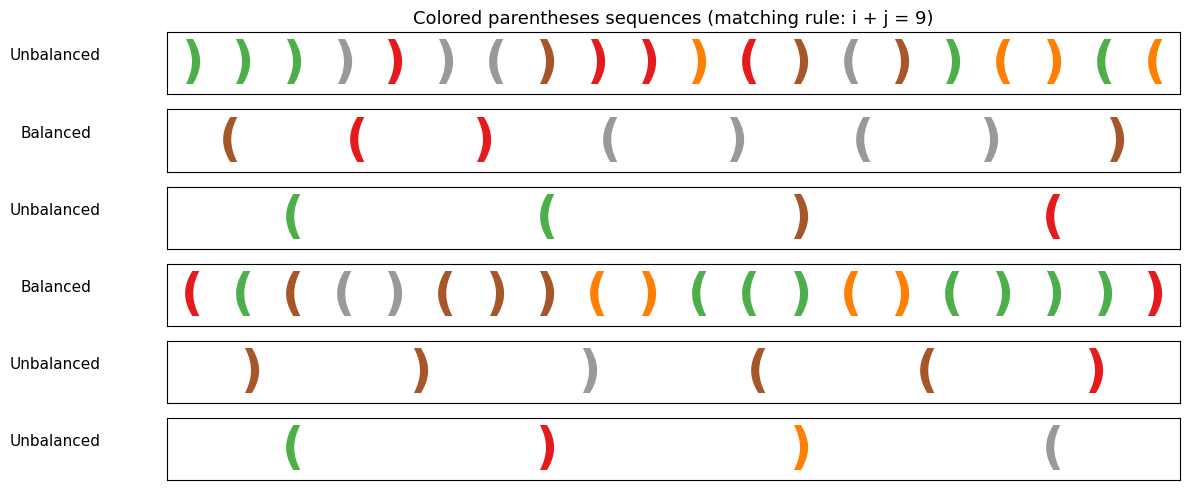

In [8]:
# Visualize a few examples
pair_colors = plt.cm.Set1(np.linspace(0, 1, 5))

fig, axes = plt.subplots(6, 1, figsize=(12, 5))
for ax in axes:
    x, l = gen.generate_input(hard_false=False)
    seq = x.argmax(dim=1).numpy()
    label = "Balanced" if l.item() == 1 else "Unbalanced"
    for t, s in enumerate(seq):
        pair_id = s if s < 5 else 9 - s
        char = "(" if s < 5 else ")"
        ax.text(
            t,
            0.5,
            char,
            ha="center",
            va="center",
            fontsize=35,
            fontweight="bold",
            color=pair_colors[pair_id],
        )
    ax.set_xlim(-0.5, len(seq) - 0.5)
    ax.set_ylim(0, 1)
    ax.set_yticks([])
    ax.set_xticks([])
    ax.set_ylabel(label, fontsize=11, rotation=0, labelpad=80)

axes[0].set_title(
    "Colored parentheses sequences (matching rule: i + j = 9)", fontsize=13
)
plt.tight_layout()
plt.show()

In [9]:
def train_rnn(model, generator, nb_train=40000, lr=1e-3, hard_false=False):
    """Train an RNN on the parentheses task. Returns per-step loss and accuracy."""
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    loss_history = []
    correct_history = []

    for k in range(nb_train):
        x, l = generator.generate_input(hard_false=hard_false)
        y = model(x)
        loss = criterion(y, l)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        loss_history.append(loss.item())
        correct_history.append((y.argmax(dim=1) == l).item())

    window = nb_train // 50
    final_acc = np.mean(correct_history[-window:])
    print(f"Final accuracy (last {window} steps): {final_acc:.2%}")
    return loss_history, correct_history


def plot_results(results, nb_train=40000):
    """Plot loss and accuracy curves with running mean smoothing."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
    window = nb_train // 50

    for name, loss_h, acc_h in results:
        ax1.plot(running_mean(loss_h, window), label=name, alpha=0.8)
        ax2.plot(running_mean(acc_h, window), label=name, alpha=0.8)

    ax1.set_xlabel("Steps")
    ax1.set_ylabel("Loss")
    ax1.set_title("Training Loss")
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    ax2.set_xlabel("Steps")
    ax2.set_ylabel("Accuracy")
    ax2.set_title("Training Accuracy")
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

## Elman Network (1990)

The simplest RNN architecture. At each time step, the hidden state is updated as:

$$
h_t = \text{ReLU}(W_{xh}\, x_t + W_{hh}\, h_{t-1} + b_h)
$$

After processing the entire sequence, the final hidden state is fed to a linear classifier:

$$
y = W_{hy}\, h_T + b_y
$$

In [10]:
class RecNet(nn.Module):
    def __init__(self, dim_input, dim_recurrent, dim_output):
        super(RecNet, self).__init__()
        self.fc_x2h = nn.Linear(dim_input, dim_recurrent)
        self.fc_h2h = nn.Linear(dim_recurrent, dim_recurrent, bias=False)
        self.fc_h2y = nn.Linear(dim_recurrent, dim_output)

    def forward(self, x):
        h = x.new_zeros(1, self.fc_h2y.weight.size(1))
        for t in range(x.size(0)):
            h = torch.relu(self.fc_x2h(x[t, :]) + self.fc_h2h(h))
        return self.fc_h2y(h)

In [11]:
nb_symbol = 10
nb_train = 40000
learning_rate = 1e-3

generator = SequenceGenerator(
    nb_symbol=nb_symbol, seq_min_len=seq_min_len, seq_max_len=seq_max_len
)

rnn_elman = RecNet(dim_input=nb_symbol, dim_recurrent=50, dim_output=2)
print(f"Elman RNN — {sum(p.numel() for p in rnn_elman.parameters())} parameters")
loss_elman, acc_elman = train_rnn(
    rnn_elman, generator, nb_train=nb_train, lr=learning_rate
)

Elman RNN — 3152 parameters
Final accuracy (last 800 steps): 99.75%


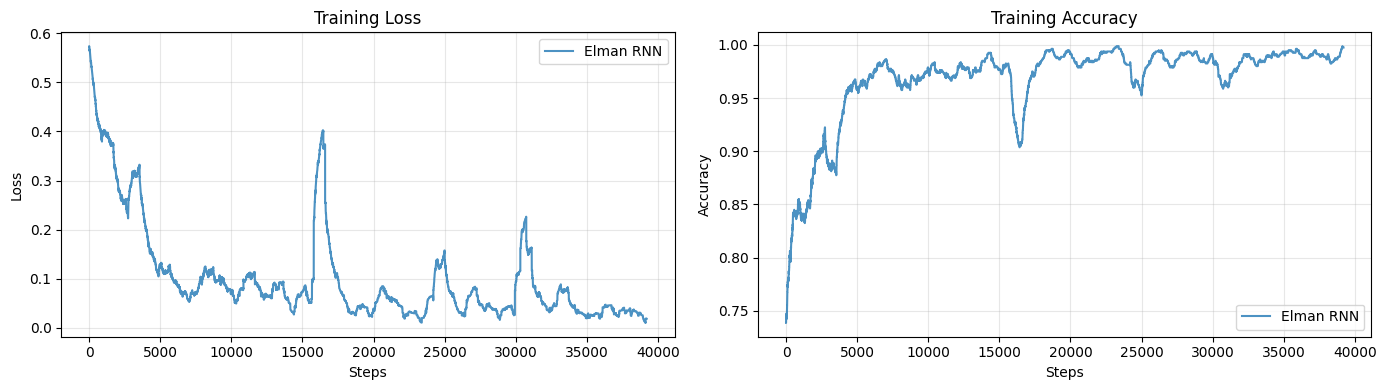

In [12]:
plot_results([("Elman RNN", loss_elman, acc_elman)], nb_train=nb_train)

## Gating Mechanisms

The Elman RNN updates its hidden state entirely at each step. This makes it hard to **remember** information over long sequences — the same problem as vanishing gradients in deep networks.

The key idea behind gating is to let the network learn **when to update** and **when to keep** its hidden state. A **gate** $z_t$ is a sigmoid layer that outputs values between 0 and 1, controlling how much information flows through:

$$
\bar{h}_t = \text{ReLU}(W_{xh}\, x_t + W_{hh}\, h_{t-1} + b_h)
$$
$$
z_t = \sigma(W_{xz}\, x_t + W_{hz}\, h_{t-1} + b_z)
$$
$$
h_t = z_t \odot h_{t-1} + (1 - z_t) \odot \bar{h}_t
$$

- When $z_t \approx 1$: **copy** the previous state (remember)
- When $z_t \approx 0$: **use** the new candidate (update)

This is analogous to **residual connections** (see [Chapter 7](../7-deep/limits-of-depth.ipynb)): the gate provides a direct path for gradients to flow backward through time.

In [13]:
class RecNetGating(nn.Module):
    def __init__(self, dim_input, dim_recurrent, dim_output):
        super(RecNetGating, self).__init__()
        self.fc_x2h = nn.Linear(dim_input, dim_recurrent)
        self.fc_h2h = nn.Linear(dim_recurrent, dim_recurrent, bias=False)
        self.fc_x2z = nn.Linear(dim_input, dim_recurrent)
        self.fc_h2z = nn.Linear(dim_recurrent, dim_recurrent, bias=False)
        self.fc_h2y = nn.Linear(dim_recurrent, dim_output)

    def forward(self, x):
        h = x.new_zeros(1, self.fc_h2y.weight.size(1))
        for t in range(x.size(0)):
            z = torch.sigmoid(self.fc_x2z(x[t, :]) + self.fc_h2z(h))
            hb = torch.relu(self.fc_x2h(x[t, :]) + self.fc_h2h(h))
            h = z * h + (1 - z) * hb
        return self.fc_h2y(h)

In [14]:
rnn_gated = RecNetGating(dim_input=nb_symbol, dim_recurrent=50, dim_output=2)
print(f"Gated RNN — {sum(p.numel() for p in rnn_gated.parameters())} parameters")
loss_gated, acc_gated = train_rnn(
    rnn_gated, generator, nb_train=nb_train, lr=learning_rate
)

Gated RNN — 6202 parameters
Final accuracy (last 800 steps): 99.00%


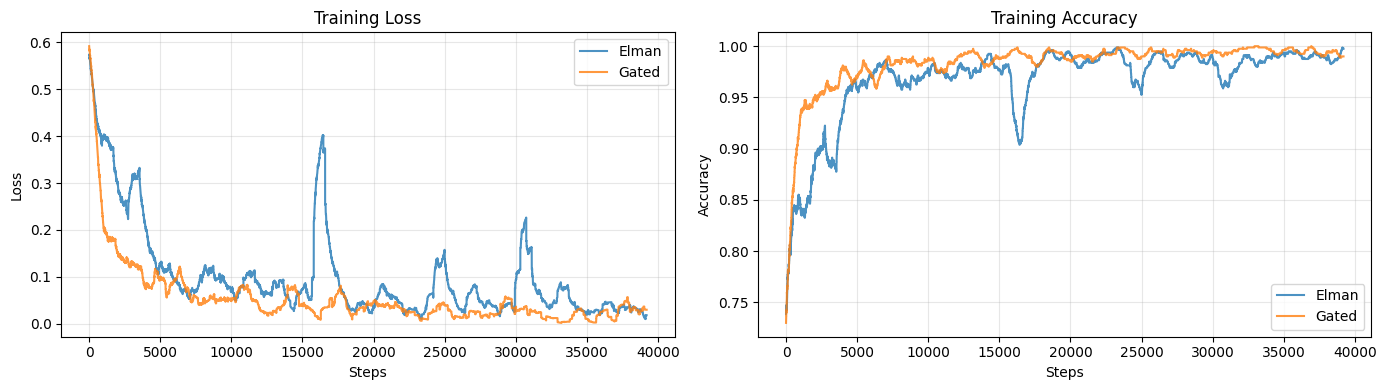

In [15]:
plot_results(
    [("Elman", loss_elman, acc_elman), ("Gated", loss_gated, acc_gated)],
    nb_train=nb_train,
)

## GRU — Gated Recurrent Unit

The GRU extends the simple gating mechanism with a **reset gate** $r_t$ that controls how much of the previous hidden state influences the candidate:

<img src="imgs/gru.png" height="280">

_Source: [Christopher Olah's blog](https://colah.github.io/posts/2015-08-Understanding-LSTMs/)_

$$
r_t = \sigma(W_{xr}\, x_t + W_{hr}\, h_{t-1} + b_r) \qquad \text{(reset gate)}
$$
$$
z_t = \sigma(W_{xz}\, x_t + W_{hz}\, h_{t-1} + b_z) \qquad \text{(update gate)}
$$
$$
\bar{h}_t = \tanh(W_{xh}\, x_t + W_{hh}\, (r_t \odot h_{t-1}) + b_h) \qquad \text{(candidate)}
$$
$$
h_t = z_t \odot h_{t-1} + (1 - z_t) \odot \bar{h}_t \qquad \text{(hidden state)}
$$

When $r_t \approx 0$, the candidate ignores the previous state — the network can learn to "reset" its memory.

In [16]:
class GRUNet(nn.Module):
    def __init__(self, dim_input, dim_recurrent, dim_output):
        super(GRUNet, self).__init__()
        self.gru = nn.GRU(input_size=dim_input, hidden_size=dim_recurrent)
        self.fc_h2y = nn.Linear(dim_recurrent, dim_output)

    def forward(self, x):
        x = x.unsqueeze(1)  # [seq_len, 1, dim_input]
        output, _ = self.gru(x)
        # Take the last time step
        return self.fc_h2y(F.relu(output[-1]))

In [17]:
rnn_gru = GRUNet(dim_input=nb_symbol, dim_recurrent=50, dim_output=2)
print(f"GRU — {sum(p.numel() for p in rnn_gru.parameters())} parameters")
loss_gru, acc_gru = train_rnn(rnn_gru, generator, nb_train=nb_train, lr=learning_rate)

GRU — 9402 parameters
Final accuracy (last 800 steps): 99.62%


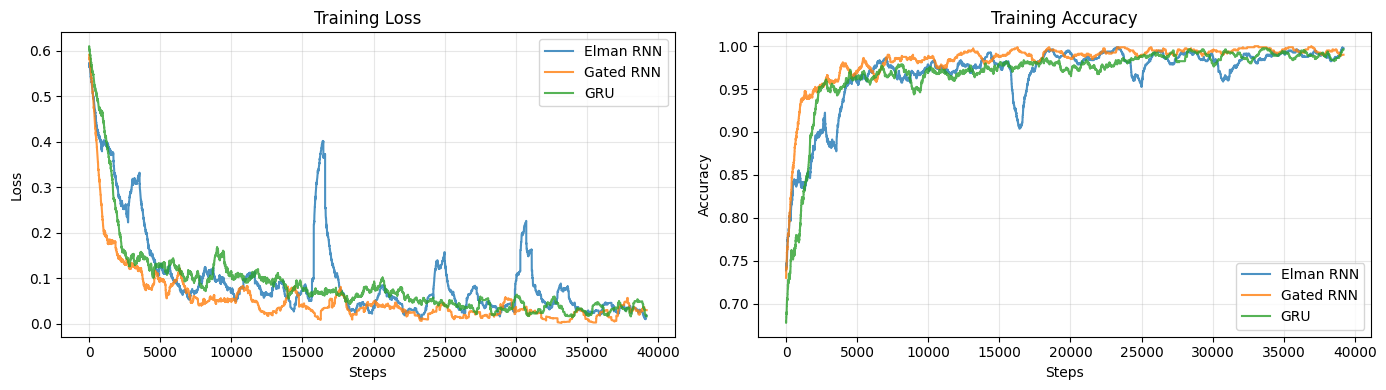

In [18]:
plot_results(
    [
        ("Elman RNN", loss_elman, acc_elman),
        ("Gated RNN", loss_gated, acc_gated),
        ("GRU", loss_gru, acc_gru),
    ],
    nb_train=nb_train,
)

## LSTM — Long Short-Term Memory

The LSTM introduces a separate **cell state** $c_t$ that acts as a memory highway, controlled by three gates:

<img src="imgs/lstm_0.png" width="700">

**The cell state** runs through the entire chain with only minor linear interactions, allowing information to flow unchanged:

<img src="imgs/lstm_1.png" height="200">

**Forget gate** — decides what to discard from the cell state:

$$
f_t = \sigma(W_{xf}\, x_t + W_{hf}\, h_{t-1} + b_f)
$$

<img src="imgs/lstm_2.png" height="200">

**Input gate** — decides which new information to store:

$$
i_t = \sigma(W_{xi}\, x_t + W_{hi}\, h_{t-1} + b_i)
$$
$$
\tilde{c}_t = \tanh(W_{xc}\, x_t + W_{hc}\, h_{t-1} + b_c)
$$

<img src="imgs/lstm_3.png" height="200">

**Cell state update** — combines forget and input:

$$
c_t = f_t \odot c_{t-1} + i_t \odot \tilde{c}_t
$$

<img src="imgs/lstm_4.png" height="200">

**Output gate** — decides what to output based on the filtered cell state:

$$
o_t = \sigma(W_{xo}\, x_t + W_{ho}\, h_{t-1} + b_o)
$$
$$
h_t = o_t \odot \tanh(c_t)
$$

<img src="imgs/lstm_5.png" height="200">

_Source: [Christopher Olah's blog](https://colah.github.io/posts/2015-08-Understanding-LSTMs/)_

The cell state $c_t$ provides an **uninterrupted gradient highway** — analogous to skip connections in ResNets (see [Chapter 7](../7-deep/limits-of-depth.ipynb)).

In [19]:
class LSTMNet(nn.Module):
    def __init__(self, dim_input, dim_recurrent, num_layers, dim_output):
        super(LSTMNet, self).__init__()
        self.lstm = nn.LSTM(
            input_size=dim_input, hidden_size=dim_recurrent, num_layers=num_layers
        )
        self.fc_h2y = nn.Linear(dim_recurrent, dim_output)

    def forward(self, x):
        x = x.unsqueeze(1)  # [seq_len, 1, dim_input]
        output, _ = self.lstm(x)
        # Take the last time step
        return self.fc_h2y(F.relu(output[-1]))

In [20]:
rnn_lstm_2 = LSTMNet(dim_input=nb_symbol, dim_recurrent=50, num_layers=2, dim_output=2)
print(f"LSTM (2 layers) — {sum(p.numel() for p in rnn_lstm_2.parameters())} parameters")
loss_lstm_2, acc_lstm_2 = train_rnn(
    rnn_lstm_2, generator, nb_train=nb_train, lr=learning_rate
)

LSTM (2 layers) — 32902 parameters
Final accuracy (last 800 steps): 99.12%


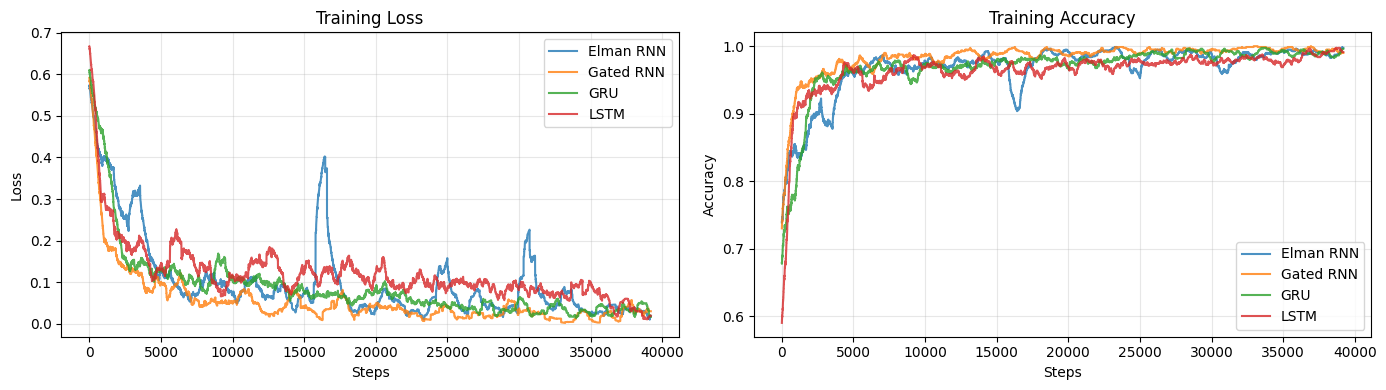

In [21]:
plot_results(
    [
        ("Elman RNN", loss_elman, acc_elman),
        ("Gated RNN", loss_gated, acc_gated),
        ("GRU", loss_gru, acc_gru),
        ("LSTM", loss_lstm_2, acc_lstm_2),
    ],
    nb_train=nb_train,
)

## Multi-layer RNNs

Just like feedforward networks, RNNs can be **stacked**: the output of one recurrent layer becomes the input of the next. This allows the network to learn hierarchical temporal representations.

<img src="imgs/deep_rnn.png" width="280">

_Source: [Dataflowr Module 11](https://dataflowr.github.io/slides/module11.html)_

In [22]:
rnn_lstm_4 = LSTMNet(
    dim_input=nb_symbol, dim_recurrent=50, num_layers=4, dim_output=2
)
print(f"LSTM 4-layer — {sum(p.numel() for p in rnn_lstm_4.parameters())} parameters")
loss_lstm_4, acc_lstm_4 = train_rnn(
    rnn_lstm_4, generator, nb_train=nb_train, lr=learning_rate
)

LSTM 4-layer — 73702 parameters
Final accuracy (last 800 steps): 97.75%


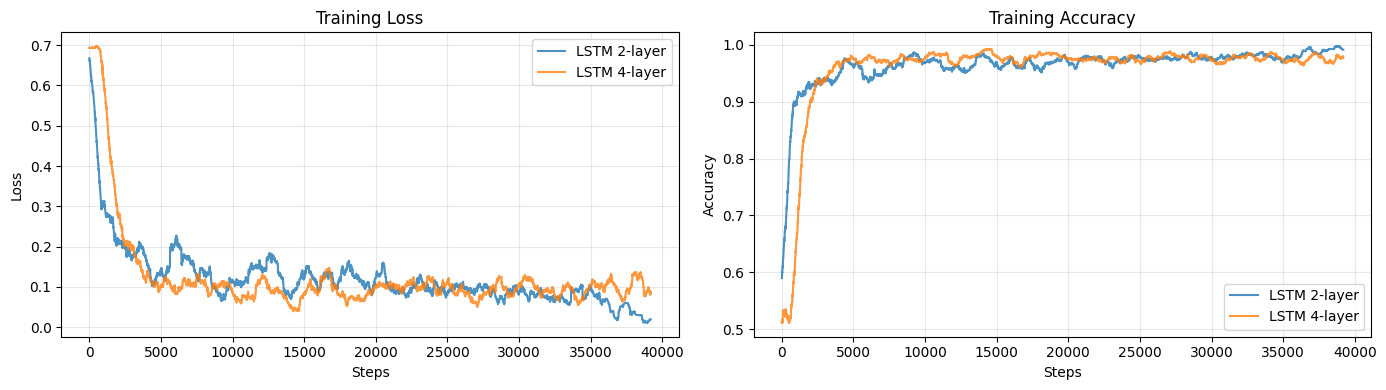

In [23]:
plot_results(
    [("LSTM 2-layer", loss_lstm_2, acc_lstm_2), ("LSTM 4-layer", loss_lstm_4, acc_lstm_4)],
    nb_train=nb_train,
)

Jozefowicz et al. (2015) conducted an extensive exploration of different recurrent architectures:

> *"We have evaluated a variety of recurrent neural network architectures in order to find an architecture that reliably outperforms the LSTM. Though there were architectures that outperformed the LSTM on some problems, we were unable to find an architecture that consistently beat the LSTM and the GRU in all experimental conditions."*

## Generalization

How well do these architectures generalize? We test each model on three conditions:

1. **Valid only** — balanced sequences of maximum training length. Does the model correctly recognize valid inputs?
2. **Hard negatives** — structurally invalid negatives at maximum training length (not random).
3. **Longer sequences** — sequences longer than anything seen during training (concatenation of two length-20 sequences).

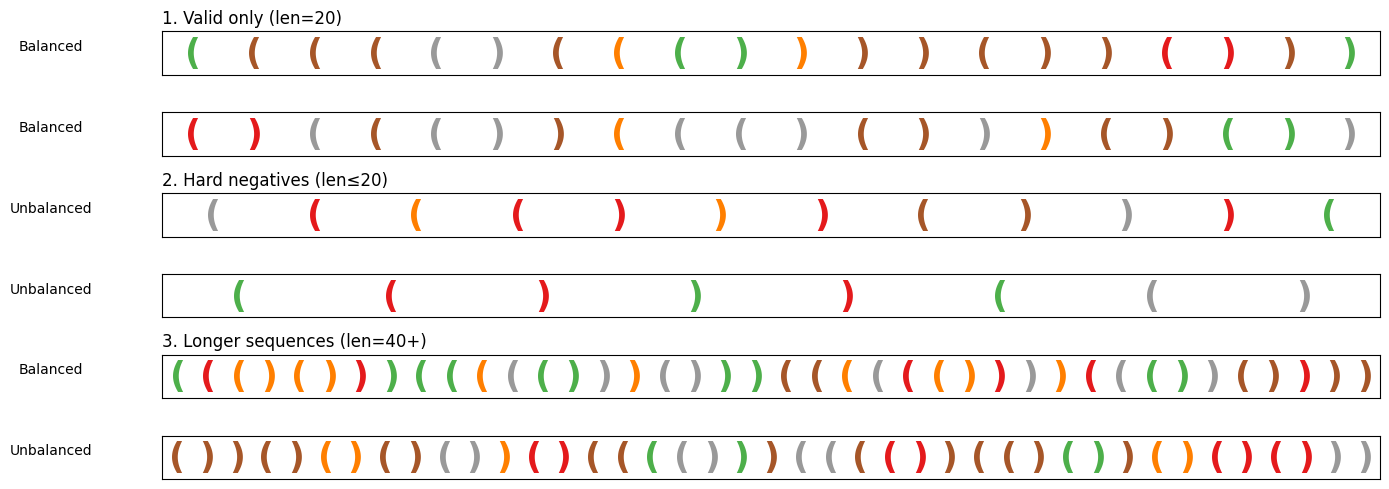

In [24]:
# Illustrate the three generalization conditions
pair_colors = plt.cm.Set1(np.linspace(0, 1, 5))


def plot_seq(ax, seq, label):
    for t, s in enumerate(seq):
        pair_id = s if s < 5 else 9 - s
        char = "(" if s < 5 else ")"
        ax.text(t, 0.5, char, ha="center", va="center", fontsize=25,
                fontweight="bold", color=pair_colors[pair_id])
    ax.set_xlim(-0.5, len(seq) - 0.5)
    ax.set_ylim(0, 1)
    ax.set_yticks([])
    ax.set_xticks([])
    ax.set_ylabel(label, fontsize=10, rotation=0, labelpad=80)


gen = SequenceGenerator(nb_symbol=10, seq_min_len=seq_min_len, seq_max_len=seq_max_len)

fig, axes = plt.subplots(6, 1, figsize=(14, 5))

# Condition 1: Valid only (len=seq_max_len)
for ax in axes[0:2]:
    seq = gen.generate_pattern_parenthesis(len_r=seq_max_len)
    plot_seq(ax, seq, "Balanced")
axes[0].set_title(f"1. Valid only (len={seq_max_len})", fontsize=12, loc="left")

# Condition 2: Hard negatives (len=seq_max_len)
for ax in axes[2:4]:
    seq = gen.generate_parenthesis_false()
    plot_seq(ax, seq, "Unbalanced")
axes[2].set_title(f"2. Hard negatives (len≤{seq_max_len})", fontsize=12, loc="left")

# Condition 3: Longer sequences (2 x seq_max_len)
seq = gen.generate_hard_parenthesis(seq_max_len)
plot_seq(axes[4], seq, "Balanced")
seq = gen.generate_hard_nonparenthesis(seq_max_len)
plot_seq(axes[5], seq, "Unbalanced")
axes[4].set_title(f"3. Longer sequences (len={2*seq_max_len}+)", fontsize=12, loc="left")

plt.tight_layout()
plt.show()

In [25]:
def test_model(model, generator, nb_test=1000):
    """Evaluate a model on three generalization conditions."""
    model.eval()
    with torch.no_grad():
        # Valid only
        c = sum(
            (model(x).argmax(1) == l).item()
            for x, l in [
                generator.generate_input(len_r=seq_max_len, true_parent=True)
                for _ in range(nb_test)
            ]
        )
        valid_acc = c / nb_test

        # Hard negatives
        c = sum(
            (model(x).argmax(1) == l).item()
            for x, l in [
                generator.generate_input(len_r=seq_max_len, hard_false=True)
                for _ in range(nb_test)
            ]
        )
        hard_acc = c / nb_test

        # Longer sequences
        c = sum(
            (model(x).argmax(1) == l).item()
            for x, l in [generator.generate_input_hard() for _ in range(nb_test)]
        )
        long_acc = c / nb_test

        # Longer sequences (valid only)
        c = sum(
            (model(x).argmax(1) == l).item()
            for x, l in [
                generator.generate_input_hard(true_parent=True) for _ in range(nb_test)
            ]
        )
        long_valid_acc = c / nb_test

    print(f"  Valid only (len={seq_max_len}):        {valid_acc:.1%}")
    print(f"  Hard negatives (len={seq_max_len}):    {hard_acc:.1%}")
    print(f"  Longer sequences (mixed):    {long_acc:.1%}")
    print(f"  Longer sequences (valid):    {long_valid_acc:.1%}")

### Elman RNN

In [26]:
print("Elman RNN — generalization:")
test_model(rnn_elman, generator)

Elman RNN — generalization:
  Valid only (len=20):        100.0%
  Hard negatives (len=20):    82.3%
  Longer sequences (mixed):    51.5%
  Longer sequences (valid):    99.9%


### Gated RNN

In [27]:
print("Gated RNN — generalization:")
test_model(rnn_gated, generator)

Gated RNN — generalization:
  Valid only (len=20):        100.0%
  Hard negatives (len=20):    85.2%
  Longer sequences (mixed):    50.6%
  Longer sequences (valid):    100.0%


### GRU RNN

In [28]:
print("GRU RNN — generalization:")
test_model(rnn_gru, generator)

GRU RNN — generalization:
  Valid only (len=20):        100.0%
  Hard negatives (len=20):    97.6%
  Longer sequences (mixed):    65.2%
  Longer sequences (valid):    100.0%


### LSTM

In [29]:
print("LSTM (2-layer) — generalization:")
test_model(rnn_lstm_2, generator)

LSTM (2-layer) — generalization:
  Valid only (len=20):        100.0%
  Hard negatives (len=20):    99.2%
  Longer sequences (mixed):    80.4%
  Longer sequences (valid):    100.0%


In [30]:
print("LSTM (4-layer) — generalization:")
test_model(rnn_lstm_4, generator)

LSTM (4-layer) — generalization:
  Valid only (len=20):        100.0%
  Hard negatives (len=20):    100.0%
  Longer sequences (mixed):    98.9%
  Longer sequences (valid):    100.0%
